# SignalDesk Workflow Analysis Health Check



## Introduction
SignalDesk is an internal tool that helps teams speed up repetitive work using AI-assisted workflows. The team recently changed some prompts and review policies. This notebook analyzes 7 days of usage data from three workflows (Lead summary, Reply draft, Feedback clustering) to understand what's working, what looks suspicious and what needs immediate attention.




## 1. Import and Load Data

In [1]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
#Load Data
workflow_events = pd.read_csv('product_usage_events.csv')

##2. Data Inspection

In [3]:
#Display first 5 rows
workflow_events.head()

,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes
0,2026-08-01,Sales,Lead summary,email,42,35,29,3,8.5,0.74,4.1,normal day
1,2026-08-01,Sales,Lead summary,manual,18,12,8,2,6.0,0.61,3.8,normal day
2,2026-08-01,Support,Reply draft,queue,55,48,39,6,4.5,0.82,4.0,normal day
3,2026-08-01,Support,Reply draft,manual,11,8,5,1,3.0,0.68,NaN,missing rating
4,2026-08-01,Product,Feedback clustering,csv upload,12,9,6,2,14.0,0.59,3.6,small sample


In [4]:
#Explore data
display(workflow_events)

,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes
0,2026-08-01,Sales,Lead summary,email,42,35,29,3,8.5,0.74,4.1,normal day
1,2026-08-01,Sales,Lead summary,manual,18,12,8,2,6.0,0.61,3.8,normal day
2,2026-08-01,Support,Reply draft,queue,55,48,39,6,4.5,0.82,4.0,normal day
3,2026-08-01,Support,Reply draft,manual,11,8,5,1,3.0,0.68,NaN,missing rating
4,2026-08-01,Product,Feedback clustering,csv upload,12,9,6,2,14.0,0.59,3.6,small sample
5,2026-08-01,Product,Feedback clustering,manual,5,4,3,1,11.0,0.55,3.5,small sample
6,2026-08-02,Sales,Lead summary,email,46,38,31,3,8.2,0.76,4.2,normal day
7,2026-08-02,Sales,Lead summary,manual,20,14,9,2,6.4,0.63,3.9,normal day
8,2026-08-02,Support,Reply draft,queue,61,52,41,7,4.2,0.83,4.1,normal day
9,2026-08-02,Support,Reply draft,manual,12,9,6,1,3.2,0.69,3.7,normal day


In [5]:
#Understand data
workflow_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                41 non-null     object 
 1   team                41 non-null     object 
 2   workflow            41 non-null     object 
 3   source              41 non-null     object 
 4   sessions            41 non-null     int64  
 5   completed           41 non-null     int64  
 6   accepted_output     41 non-null     int64  
 7   flagged_for_review  41 non-null     int64  
 8   avg_minutes_saved   41 non-null     float64
 9   median_confidence   40 non-null     float64
 10  user_rating         40 non-null     float64
 11  notes               41 non-null     object 
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ KB


In [6]:
#list all columns
workflow_events.columns.tolist()

['date',
 'team',
 'workflow',
 'source',
 'sessions',
 'completed',
 'accepted_output',
 'flagged_for_review',
 'avg_minutes_saved',
 'median_confidence',
 'user_rating',
 'notes']

##3. Data Cleaning

In [17]:
#check missing values
workflow_events.isnull().sum()

,0
date,0
team,0
workflow,0
source,0
sessions,0
completed,0
accepted_output,0
flagged_for_review,0
avg_minutes_saved,0
median_confidence,0


In [16]:
# Remove missing values
workflow_events = workflow_events.dropna(subset=['user_rating', 'median_confidence'])

In [9]:
# Remove duplicate rows
workflow_events = workflow_events.drop_duplicates()

In [10]:
# Fix team name casing
workflow_events['team'] = workflow_events['team'].str.capitalize()

##4. KPIs & Workflow Performance
Calculate key performance indicators and aggregate by workflow to identify what's working and what needs attention.

In [11]:
# Calculate key performance indicators
workflow_events['completion_rate'] = workflow_events['completed'] / workflow_events['sessions']
workflow_events['acceptance_rate'] = workflow_events['accepted_output'] / workflow_events['completed']
workflow_events['review_rate'] = workflow_events['flagged_for_review'] / workflow_events['completed']

In [12]:
# Average performance by workflow
workflow_summary = workflow_events.groupby('workflow')[['user_rating', 'acceptance_rate', 'review_rate', 'completion_rate']].mean()

workflow_summary

,user_rating,acceptance_rate,review_rate,completion_rate
workflow,,,,
Feedback clustering,3.669231,0.655535,0.191365,0.687834
Lead summary,4.185714,0.781206,0.093754,0.776488
Reply draft,3.816667,0.711222,0.184758,0.776175


## 5. The problem
Investigate why Support Reply draft crashed on Aug 7 after the review policy change.

In [13]:
# Support Reply performance before Aug 7
support_before = workflow_events[(workflow_events['workflow'] == 'Reply draft') & (workflow_events['date'] < '2026-08-07')]
support_before[['user_rating', 'acceptance_rate', 'review_rate']].mean()

,0
user_rating,3.972727
acceptance_rate,0.733098
review_rate,0.137383


In [14]:
# Support Reply performance on Aug 7
support_aug7 = workflow_events[(workflow_events['workflow'] == 'Reply draft') & (workflow_events['date'] == '2026-08-07')]
support_aug7[['user_rating', 'acceptance_rate', 'review_rate']].mean()

,0
user_rating,2.100000
acceptance_rate,0.470588
review_rate,0.705882


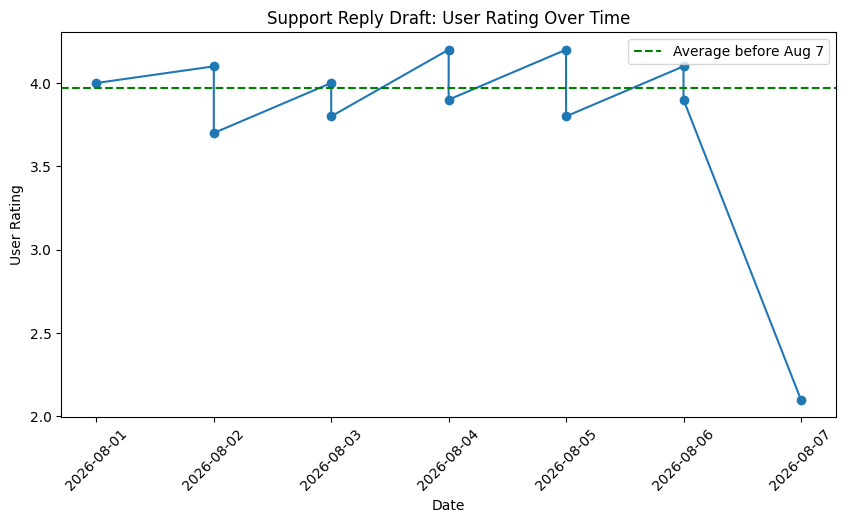

In [15]:
# User rating over time for Support Reply draft
reply_draft = workflow_events[workflow_events['workflow'] == 'Reply draft']

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(reply_draft['date'], reply_draft['user_rating'], marker='o')
plt.axhline(y=3.97, color='green', linestyle='--', label='Average before Aug 7')
plt.xlabel('Date')
plt.ylabel('User Rating')
plt.title('Support Reply Draft: User Rating Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 6. Conclusion

###Most useful Workflow:
*   **Lead summary** is the most useful workflow, with the highest user rating (4.19), strongest acceptance rate (78%) and lowest flag rate (9%). This workflow is performing well and should continue as-is.

###Least trustworthy metric:
*  **Model confidence** is the least trustworthy metric. On Aug 7, the model reported 91% confidence while users rated the output 2.1. Confidence does not equal quality. Rely on user ratings instead when evaluating workflow performance.

We looked at all three workflows(Lead summary, Reply draft,Feedback clustering) and compared them side-by-side.
 Lead summary came out on top, users like it best, they use it most and it has the fewest problems.

### The Problem: Aug 7 Policy Change

Support Reply crashed after the policy change.
- Before: rating 3.97, acceptance 73%, flags 14%.
- After:  rating 2.1, acceptance 47%, flags 71%.

The policy change made the workflow significantly worse, not better.

### What to do next:
1. **Review and revert the Aug 7 policy change.** It's making Support Reply worse, not better.
2. **Going forward:** Implement a weekly health check for each workflow tracking three metrics:
   - User rating
   - Acceptance rate
   - Problems flagged
3. If anything drops dramatically week-to-week, investigate immediately.

